# Project Milestone One: Form Your Team, Understand the Problem, and Explore the Data

#### **Due:** July 12th @ 11:59 PM (with a 2 hour & 1 minute grace period)

#### **Important:** There is **no late period** for this assignment, as manual grading must begin immediately after the deadline.

## What You Will Do in This Milestone

1. Form your project team and complete the **Team Contract** (available in the Homework Repository). Submit one copy to Gradescope.
2. Select a **team leader**, who will submit this notebook on behalf of the team after everyone has contributed to the assignment. This <a href=https://guides.gradescope.com/hc/en-us/articles/21863861823373-Adding-Group-Members-to-a-Submission>Gradescope guide</a> explains how to add group members to a submission.
3. After completing this milestone, **each team member** must complete an **Individual Team Evaluation** (available in the Homework Repository) and submit it individually to Gradescope.
4. Complete a simplified version of the **Machine Learning Project Checklist** from Appendix A of *Hands-On Machine Learning* (p. 779):

> **Part 1:** Frame the problem and understand the project goals   
> **Part 2:** Explore and understand the dataset   
> **Part 3:** Clean and prepare the data   
> **Part 4:** Investigate feature relationships   
> **Part 5:** Develop hypotheses for feature engineering and preprocessing

## The Dataset

All teams will work with the same dataset: a reduced version of the Zillow housing dataset used in the **Zillow Prize** competition on Kaggle in 2017 (unfortunately, the competition has long since ended!).

Your goal is to predict a property's **assessed tax value** (`taxvaluedollarcnt`) from a large collection of property characteristics. The dataset contains many of the challenges encountered in real machine learning projects, including:

* Missing values
* Potential outliers
* Redundant and highly correlated features
* Identifier variables that may not be useful for prediction
* Features that require careful interpretation before preprocessing

Unlike many educational datasets, this one has **not** been extensively preprocessed. Throughout this milestone, your objective is to understand the data, identify potential issues, and develop hypotheses about preprocessing and feature engineering. In **Milestone 2**, you will evaluate many of these ideas experimentally to determine whether they actually improve model performance.



In [1]:
#%pip install numpy pandas matplotlib seaborn scikit-learn tqdm requests

In [2]:
# =============================
# Useful Imports
# =============================

# Standard Libraries
import os
import time
import math
import io
import zipfile
import requests
from urllib.parse import urlparse
from itertools import chain, combinations

# Data Science Libraries
import numpy as np
import pandas as pd
import seaborn as sns

# Visualization
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.ticker as mticker  # Optional: Format y-axis labels as dollars

# Scikit-learn (Machine Learning)
from sklearn.model_selection import (
    train_test_split, 
    cross_val_score, 
    GridSearchCV, 
    RandomizedSearchCV, 
    RepeatedKFold
)
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error
from sklearn.feature_selection import SequentialFeatureSelector, f_regression, SelectKBest
from sklearn.datasets import make_regression
from sklearn.ensemble import BaggingRegressor, RandomForestRegressor, GradientBoostingRegressor

# Kaggle and Progress Tracking
from tqdm import tqdm

# =============================
# Global Variables
# =============================
random_state = 42

# =============================
# Utility Functions
# =============================

# Format y-axis labels as dollars with commas (optional)
def dollar_format(x, pos):
    return f'${x:,.0f}'

# Convert seconds to HH:MM:SS format
def format_hms(seconds):
    return time.strftime("%H:%M:%S", time.gmtime(seconds))



In [3]:
import sys
print(sys.executable)
print(sys.version)

C:\Users\DELL\anaconda3\envs\myenv\python.exe
3.11.13 | packaged by Anaconda, Inc. | (main, Jun  5 2025, 13:03:15) [MSC v.1929 64 bit (AMD64)]


## Prelude: Download the Zillow Housing Dataset 

The code cell below will load the dataset for you.    

> **Notice that before downloading, this cell first checks whether the files already exist.** 

For a detailed description of the dataset features, please refer to  **Appendix 1** below. 


In [4]:

url = "https://www.cs.bu.edu/fac/snyder/cs505/Data/zillow_dataset.csv"

filename = os.path.basename(urlparse(url).path)

if not os.path.exists(filename):
    try:
        print("Downloading the file...")
        response = requests.get(url)
        response.raise_for_status()  # Raise an error for bad status codes
        with open(filename, "wb") as f:
            f.write(response.content)
        print("File downloaded successfully.")
    except requests.exceptions.RequestException as e:
        print(f"Error downloading the file: {e}")
else:
    print("File already exists. Skipping download.")

df = pd.read_csv(filename)

File already exists. Skipping download.


## Part 1: Frame the problem and look at the big picture [3 pts]

This part is a bit vague, since this project is not taking place in an actual business, but for the sake of exercising all the steps, **pretend** that you are working at Zillow as a data analyst and are given this dataset and asked to
- Analyze and understand the data; 
- Develop a regression model;
- Give a presentation to the marketing team about your results.  

#### **1 Discussion:** 

AFTER doing your EDA, come back and answer each of the following 3 questions in a *concise and informative paragraph between the lines;* you may wish to use your own business or home-buying experience, or to do some online research about the issues before you propose your ideas. (Don't stress about this, but *humor your professor and give it your best shot!*)


In [5]:
df.info()
df.describe()
df.isnull().sum()
df.corr(numeric_only=True)

<class 'pandas.DataFrame'>
RangeIndex: 77613 entries, 0 to 77612
Data columns (total 55 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   parcelid                      77613 non-null  int64  
 1   airconditioningtypeid         25007 non-null  float64
 2   architecturalstyletypeid      207 non-null    float64
 3   basementsqft                  50 non-null     float64
 4   bathroomcnt                   77579 non-null  float64
 5   bedroomcnt                    77579 non-null  float64
 6   buildingclasstypeid           15 non-null     float64
 7   buildingqualitytypeid         49809 non-null  float64
 8   calculatedbathnbr             76963 non-null  float64
 9   decktypeid                    614 non-null    float64
 10  finishedfloor1squarefeet      6037 non-null   float64
 11  calculatedfinishedsquarefeet  77378 non-null  float64
 12  finishedsquarefeet12          73923 non-null  float64
 13  finishedsqua

,parcelid,airconditioningtypeid,architecturalstyletypeid,basementsqft,bathroomcnt,bedroomcnt,buildingclasstypeid,buildingqualitytypeid,calculatedbathnbr,decktypeid,...,typeconstructiontypeid,unitcnt,yardbuildingsqft17,yardbuildingsqft26,yearbuilt,numberofstories,assessmentyear,taxdelinquencyyear,censustractandblock,taxvaluedollarcnt
parcelid,1.000000,0.152131,0.062722,0.368308,0.003232,0.006812,-0.143576,-0.047073,0.015360,NaN,...,0.074668,0.012727,-0.007449,0.151540,0.141090,0.047334,NaN,-0.034586,0.101498,0.012496
airconditioningtypeid,0.152131,1.000000,0.002189,NaN,-0.039158,0.088620,NaN,-0.037503,-0.037686,NaN,...,-0.048448,0.360055,NaN,NaN,-0.073284,0.199403,NaN,0.039543,0.800552,-0.011747
architecturalstyletypeid,0.062722,0.002189,1.000000,NaN,-0.004973,-0.003224,NaN,NaN,-0.004973,NaN,...,-0.009863,NaN,NaN,NaN,-0.118358,-0.035153,NaN,NaN,0.003596,0.003567
basementsqft,0.368308,NaN,NaN,1.000000,0.542177,0.444727,NaN,NaN,0.542177,NaN,...,NaN,NaN,0.116951,-0.799649,0.415380,0.090460,NaN,NaN,0.368088,0.493777
bathroomcnt,0.003232,-0.039158,-0.004973,0.542177,1.000000,0.635479,NaN,0.524034,1.000000,NaN,...,0.065032,0.063385,0.282866,0.033873,0.373210,0.331393,NaN,0.036793,0.001198,0.461013
bedroomcnt,0.006812,0.088620,-0.003224,0.444727,0.635479,1.000000,NaN,0.108731,0.618283,NaN,...,0.039717,0.102825,0.269724,-0.130717,0.047853,0.162904,NaN,0.013800,0.007834,0.239326
buildingclasstypeid,-0.143576,NaN,NaN,NaN,NaN,NaN,1.000000,-0.285241,NaN,NaN,...,NaN,0.110012,NaN,NaN,0.328357,0.104828,NaN,NaN,-0.066950,-0.299221
buildingqualitytypeid,-0.047073,-0.037503,NaN,NaN,0.524034,0.108731,-0.285241,1.000000,0.523392,NaN,...,NaN,-0.195326,NaN,NaN,0.571124,-0.246028,NaN,0.051004,-0.001297,0.327590
calculatedbathnbr,0.015360,-0.037686,-0.004973,0.542177,1.000000,0.618283,NaN,0.523392,1.000000,NaN,...,0.065032,0.266695,0.288718,0.033873,0.373842,0.378762,NaN,0.036186,0.002873,0.484819
decktypeid,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


**1.1:**  What is the objective of this project in business terms?

> The objective of this project is to help Zillow better estimate the assessed tax value of residential properties using information about each home. By building a regression model, Zillow can provide more accurate property valuations and better understand which property characteristics have the greatest impact on a home's assessed value. These insights can support better business decisions and improve the experience for both buyers and sellers.


**1.2:**  How will your solution be used?

> The regression model will be used to predict the assessed tax value of homes based on their characteristics. This can help Zillow provide more accurate property estimates for customers while also giving the marketing team a better understanding of the features that are most associated with higher home values. For example, our initial analysis suggests that factors such as finished living area and the number of bathrooms have a stronger relationship with assessed tax value than many other variables in the dataset.

**1.3:**  How should success (or failure) be measured?

> Success should be measured by how accurately the model predicts a property's assessed tax value on data it has not seen before. Metrics such as Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and R^2 can be used to evaluate performance. From a business perspective, success also means producing results that are reliable and easy to interpret so Zillow can make better pricing recommendations and better understand the factors that influence home values.

## Part 2: Download and perform preliminary exploration of the data [4 pts]

### Part 2.A: Load the data into a dataframe and study each feature/column and its characteristics:
- Feature Name
- Type (categorical, int/float, text, etc.)
- Apparent usefulness for the task
- Approximate % of missing values
- How many unique values

**Note:** The **target** is the last column `'taxvaluedollarcnt'` -- pay particular attention to this during the EDA process. 
  
Hint: Just use `.head()`, `.info()`, and `.nunique()`.

In [6]:
#Preview the data
df.head()

,parcelid,airconditioningtypeid,architecturalstyletypeid,basementsqft,bathroomcnt,bedroomcnt,buildingclasstypeid,buildingqualitytypeid,calculatedbathnbr,decktypeid,...,yardbuildingsqft17,yardbuildingsqft26,yearbuilt,numberofstories,fireplaceflag,assessmentyear,taxdelinquencyflag,taxdelinquencyyear,censustractandblock,taxvaluedollarcnt
0,14297519,NaN,NaN,NaN,3.5,4.0,NaN,NaN,3.5,NaN,...,NaN,NaN,1998.0,NaN,NaN,2016.0,NaN,NaN,6.059063e+13,1023282.0
1,17052889,NaN,NaN,NaN,1.0,2.0,NaN,NaN,1.0,NaN,...,NaN,NaN,1967.0,1.0,NaN,2016.0,NaN,NaN,6.111001e+13,464000.0
2,14186244,NaN,NaN,NaN,2.0,3.0,NaN,NaN,2.0,NaN,...,NaN,NaN,1962.0,1.0,NaN,2016.0,NaN,NaN,6.059022e+13,564778.0
3,12177905,NaN,NaN,NaN,3.0,4.0,NaN,8.0,3.0,NaN,...,NaN,NaN,1970.0,NaN,NaN,2016.0,NaN,NaN,6.037300e+13,145143.0
4,10887214,1.0,NaN,NaN,3.0,3.0,NaN,8.0,3.0,NaN,...,NaN,NaN,1964.0,NaN,NaN,2016.0,NaN,NaN,6.037124e+13,119407.0


In [7]:
#Examine the dataset structure
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 77613 entries, 0 to 77612
Data columns (total 55 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   parcelid                      77613 non-null  int64  
 1   airconditioningtypeid         25007 non-null  float64
 2   architecturalstyletypeid      207 non-null    float64
 3   basementsqft                  50 non-null     float64
 4   bathroomcnt                   77579 non-null  float64
 5   bedroomcnt                    77579 non-null  float64
 6   buildingclasstypeid           15 non-null     float64
 7   buildingqualitytypeid         49809 non-null  float64
 8   calculatedbathnbr             76963 non-null  float64
 9   decktypeid                    614 non-null    float64
 10  finishedfloor1squarefeet      6037 non-null   float64
 11  calculatedfinishedsquarefeet  77378 non-null  float64
 12  finishedsquarefeet12          73923 non-null  float64
 13  finishedsqua

In [8]:
#Count the number of unique values
df.nunique()

parcelid                        77414
airconditioningtypeid               5
architecturalstyletypeid            5
basementsqft                       43
bathroomcnt                        22
bedroomcnt                         16
buildingclasstypeid                 2
buildingqualitytypeid              12
calculatedbathnbr                  21
decktypeid                          1
finishedfloor1squarefeet         1787
calculatedfinishedsquarefeet     4972
finishedsquarefeet12             4868
finishedsquarefeet13               13
finishedsquarefeet15             1724
finishedsquarefeet50             1807
finishedsquarefeet6               350
fips                                3
fireplacecnt                        5
fullbathcnt                        13
garagecarcnt                       14
garagetotalsqft                   839
hashottuborspa                      1
heatingorsystemtypeid              10
latitude                        64038
longitude                       62461
lotsizesquar

In [9]:
#Calculate the percentage of missing values
missing_pct = (df.isnull().mean() * 100).round(2)
missing_pct.sort_values(ascending=False)

buildingclasstypeid             99.98
finishedsquarefeet13            99.95
basementsqft                    99.94
storytypeid                     99.94
yardbuildingsqft26              99.91
fireplaceflag                   99.78
architecturalstyletypeid        99.73
typeconstructiontypeid          99.71
finishedsquarefeet6             99.50
pooltypeid10                    99.40
decktypeid                      99.21
poolsizesum                     98.88
pooltypeid2                     98.62
hashottuborspa                  98.02
yardbuildingsqft17              96.92
taxdelinquencyyear              96.26
taxdelinquencyflag              96.26
finishedsquarefeet15            96.10
finishedsquarefeet50            92.22
finishedfloor1squarefeet        92.22
fireplacecnt                    89.32
threequarterbathnbr             86.98
pooltypeid7                     80.57
poolcnt                         79.16
numberofstories                 77.32
airconditioningtypeid           67.78
garagetotals

In [10]:
summary = pd.DataFrame({
    "Data Type": df.dtypes,
    "Missing %": missing_pct,
    "Unique Values": df.nunique()
})

summary

,Data Type,Missing %,Unique Values
parcelid,int64,0.00,77414
airconditioningtypeid,float64,67.78,5
architecturalstyletypeid,float64,99.73,5
basementsqft,float64,99.94,43
bathroomcnt,float64,0.04,22
bedroomcnt,float64,0.04,16
buildingclasstypeid,float64,99.98,2
buildingqualitytypeid,float64,35.82,12
calculatedbathnbr,float64,0.84,21
decktypeid,float64,99.21,1


#### **2.A Discussion:** 

Answer the following questions. You may wish to examine Appendix 3 before starting. 

**2.A.1:**  Which features are categorical?

> The dataset contains several categorical features, even though many of them are stored as numbers. Examples include airconditioningtypeid, buildingqualitytypeid, heatingorsystemtypeid, propertylandusetypeid, regionidcity, regionidcounty, regionidzip, and fips, which represent categories or locations rather than continuous values. The dataset also includes text-based categorical features such as propertycountylandusecode, propertyzoningdesc, fireplaceflag, and taxdelinquencyflag.

**2.A.2:**  Are there any features which appear at first glance to be **useless** for the business purpose of this project and should be deleted?  Give examples and describe your reasoning briefly. 

> Yes. Some features do not appear to add value for predicting a property's assessed tax value. For example, parcelid is simply a unique identifier for each property and does not describe the property itself. Likewise, assessmentyear only contains one unique value (2016), so it does not provide any information that helps distinguish one property from another. These features would likely be removed before building the regression model.

**2.A.3:**  Are there any features which appear to be **useless** because of the percentage of missing values?  If so, give an example. 

> Yes. Several features have such a large amount of missing data that they are unlikely to be useful. For example, buildingclasstypeid is missing almost all of its values (99.98%). Other features, such as basementsqft, finishedsquarefeet13, and storytypeid, also have more than 99% missing values. Since there is very little information available for these features, they may be better candidates for removal than imputation.

**2.A.4:**  Are there any features which appear to be **useless** because of the number of unique values?  If so, give an example. 

> Yes. Features with either too many or too few unique values may not be useful for prediction. For example, parcelid has almost one unique value for every property, making it an identifier rather than a predictive feature. On the other hand, assessmentyear only has one unique value across the entire dataset, so it does not provide any information that helps explain differences in property values.

### Part 2.B: Exploratory Data Analysis (EDA) -- Feature-Level Visualization  

- To get an overview, generate histograms for all features using `df.hist()`  (Hint: increase the figsize and set the layout to `(-1,m)` to get  `m` columns and as many rows as necessary.)
- Generate individual visualizations for the target and three (3) additional features that you believe are particularly informative or interesting (a total of four features): 
    - Use appropriate plot types (e.g., histograms and boxplots for numerical features, bar plots for categorical features) to understand distributions and identify potential outliers for these three.
    - Use as many code cells as you need, and give comments describing what each cell does.
    - Answer the discussion question posed (you should choose 3 features for which you can say something interesting in the discussion).  

**Display histograms for all numerical features**

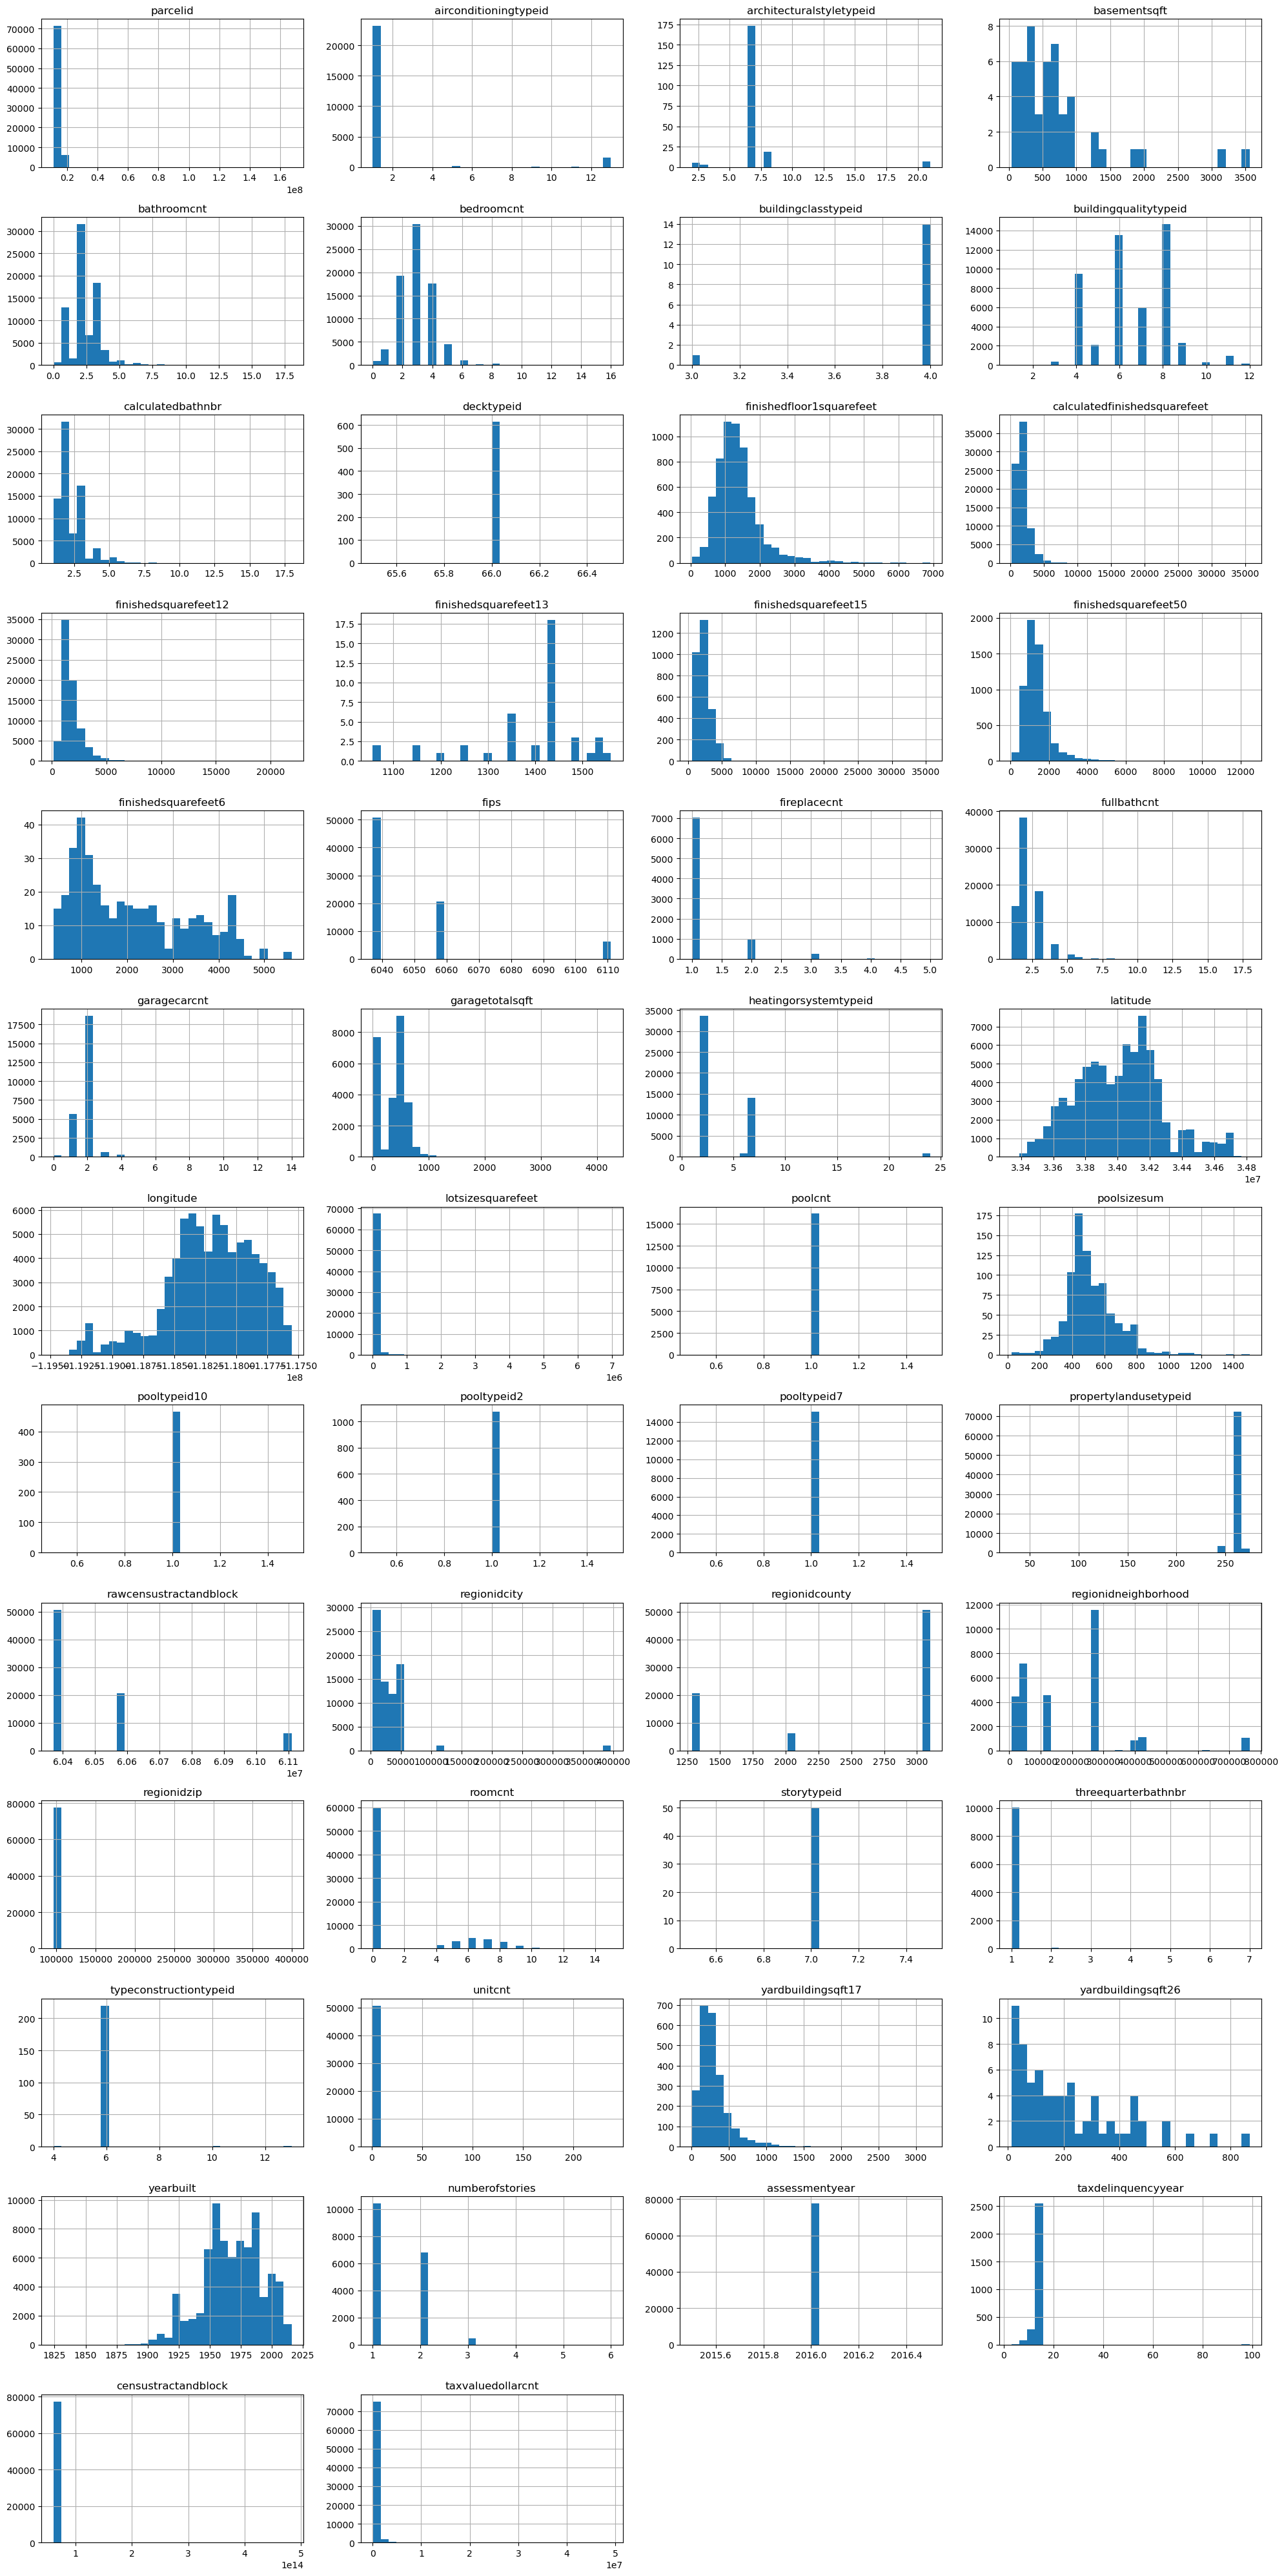

In [11]:
# Display histograms for all numerical features
df.hist(figsize=(20, 40), layout=(-1, 4), bins=30)

plt.tight_layout()
plt.show()

**Feature 1: taxvaluedollarcnt**

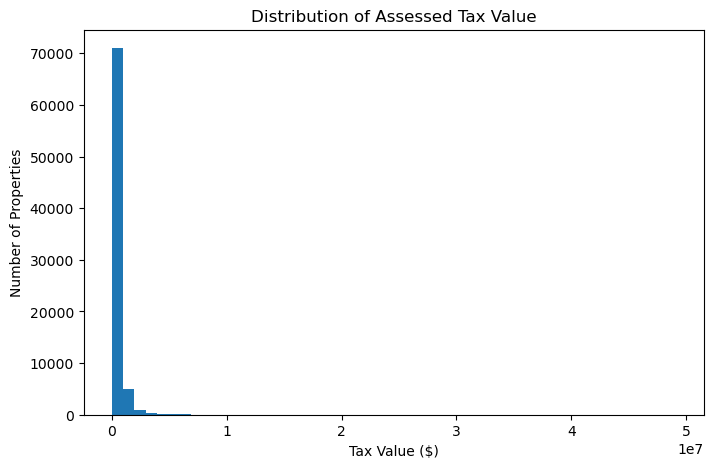

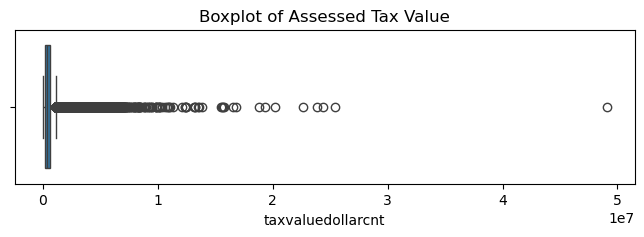

In [12]:
#Display the distribution of the target variable (assessed tax value)
plt.figure(figsize=(8,5))
plt.hist(df["taxvaluedollarcnt"].dropna(), bins=50)

plt.title("Distribution of Assessed Tax Value")
plt.xlabel("Tax Value ($)")
plt.ylabel("Number of Properties")

plt.show()

#Boxplot
#Display a boxplot to identify potential outliers in the target variable.
plt.figure(figsize=(8,2))

sns.boxplot(x=df["taxvaluedollarcnt"])

plt.title("Boxplot of Assessed Tax Value")

plt.show()

**informative features**

**Feature 2: calculated finished square feet**

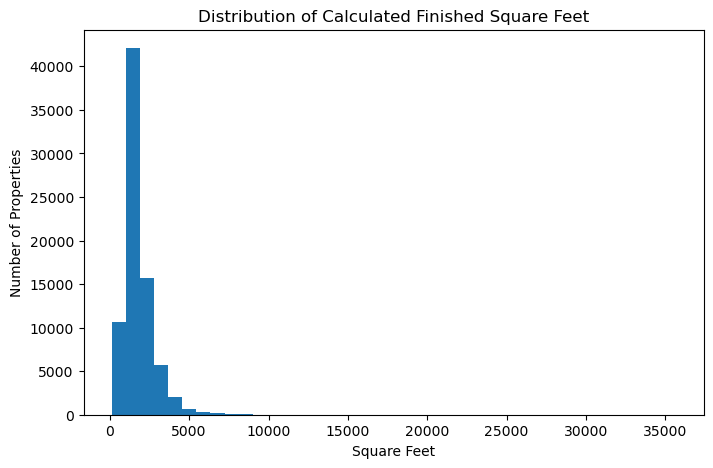

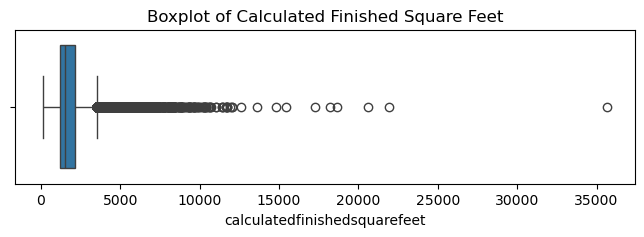

In [13]:
plt.figure(figsize=(8,5))

plt.hist(df["calculatedfinishedsquarefeet"].dropna(), bins=40)

plt.title("Distribution of Calculated Finished Square Feet")
plt.xlabel("Square Feet")
plt.ylabel("Number of Properties")

plt.show()

#Boxplot
#Display a boxplot to identify potential outliers in finished square footage.
plt.figure(figsize=(8,2))

sns.boxplot(x=df["calculatedfinishedsquarefeet"])

plt.title("Boxplot of Calculated Finished Square Feet")

plt.show()


**Feature 3: bathroomcnt**

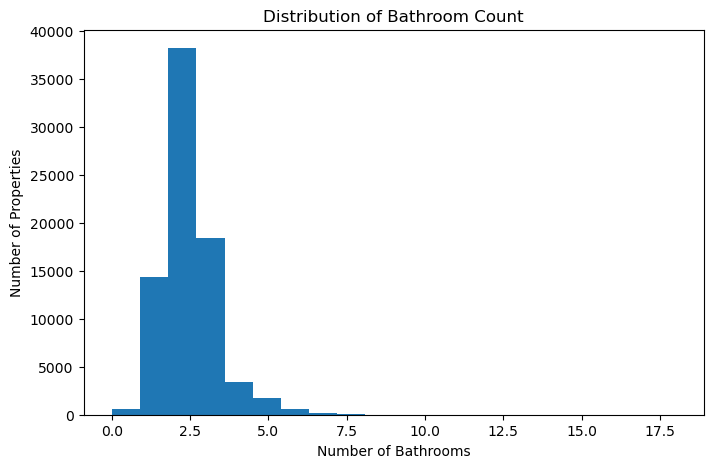

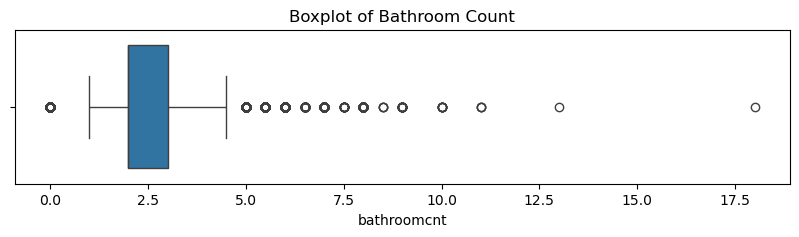

In [14]:
#Display the distribution of the number of bathrooms.

plt.figure(figsize=(8,5))
plt.hist(df["bathroomcnt"].dropna(), bins=20)

plt.title("Distribution of Bathroom Count")
plt.xlabel("Number of Bathrooms")
plt.ylabel("Number of Properties")

plt.show()

#Display a boxplot to identify potential outliers in bathroom count.
plt.figure(figsize=(10,2))
sns.boxplot(x=df["bathroomcnt"])

plt.title("Boxplot of Bathroom Count")

plt.show()

**Feature 4: yearbuilt**

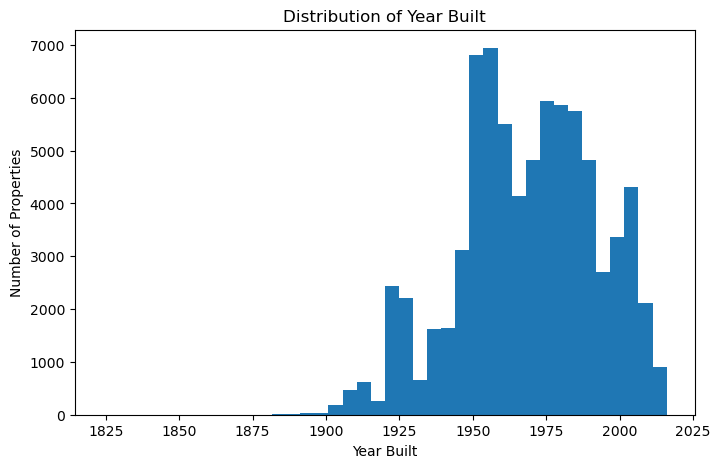

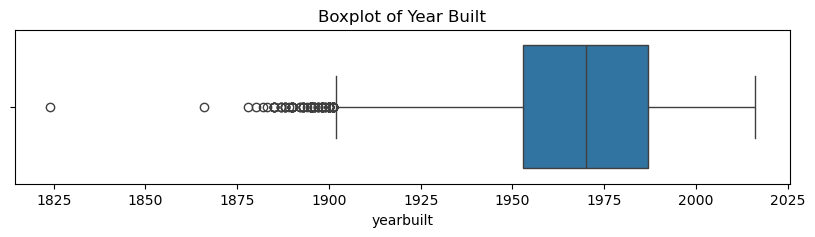

In [15]:
#Display the distribution of the year each property was built.
plt.figure(figsize=(8,5))
plt.hist(df["yearbuilt"].dropna(), bins=40)

plt.title("Distribution of Year Built")
plt.xlabel("Year Built")
plt.ylabel("Number of Properties")

plt.show()

#Display a boxplot to identify potential outliers in the year built.
plt.figure(figsize=(10,2))
sns.boxplot(x=df["yearbuilt"])

plt.title("Boxplot of Year Built")

plt.show()

#### **2.B Discussion:** 

Describe what you learned from your detailed examination of the four features you selected. For each feature, discuss:

- The overall distribution (for example, approximately normal, skewed, or multimodal).
- Any notable characteristics, such as outliers, unusual values, or missing data.
- Why you selected the feature and what you learned about the dataset from examining it.

Conclude by briefly discussing whether any of the features you examined might require additional preprocessing later in the project (such as imputation, transformation, or outlier investigation).

> **Target Variable (`taxvaluedollarcnt`)**

I selected `taxvaluedollarcnt` because it is the target variable that the regression model will predict. The distribution is heavily right-skewed, with most properties having lower assessed values and a smaller number of properties with very high values. The boxplot also shows several outliers, which is expected since home values can vary significantly. There are very few missing values, so this feature appears to be complete and should not require much preprocessing beyond evaluating the effect of the outliers.

**Calculated Finished Square Feet (`calculatedfinishedsquarefeet`)**

I selected this feature because it had one of the strongest relationships with the target variable during the initial exploration. The histogram is also right-skewed, showing that most homes have a moderate amount of finished living space while a smaller number are much larger. The boxplot identifies several large outliers that are likely legitimate high-end properties rather than data entry errors. This feature has very little missing data and appears to be an important predictor of property value.

**Bathroom Count (`bathroomcnt`)**

Bathroom count is a basic property characteristic that is likely related to a home's value. Most properties in the dataset have between two and three bathrooms, while homes with many bathrooms are much less common. The boxplot shows a few higher values that stand out, but these could simply represent larger homes. Since this feature has very few missing values, it appears to be reliable and useful for the regression model.

**Year Built (`yearbuilt`)**

I selected `yearbuilt` because the age of a home can influence its assessed value. The distribution shows that most homes in the dataset were built between the 1950s and 2000s, with fewer very old or very new homes. The boxplot identifies some older properties that fall outside the main distribution, but these appear to represent older homes rather than errors. The feature has very little missing data and should provide useful information during modeling.

**Conclusion**

looking at these four features helped identify some of the preprocessing that may be needed later in the project. Both `taxvaluedollarcnt` and `calculatedfinishedsquarefeet` are right-skewed and contain several outliers, so it may be worth exploring transformations or investigating the impact of those observations on the regression model. The features I selected have very little missing data, so imputation is probably not necessary for them. However, many of the other features in the dataset have a high percentage of missing values and will need to be evaluated before deciding whether to impute or remove them.

## Part 3:  Clean the Data: Drop, Impute, and Encode [6 pts]



**Important Notes:**
- You should review your Homework 4 before doing this section!
- Create new names for modified data at each stage to avoid problems with global variables.
- Whenever possible, write functions for all data transformations you apply, for these reasons:
    - So you can easily prepare the data the next time you get a fresh dataset
    - So you can apply these transformations in future projects
    - To clean and prepare new data instances once your solution is live
    - To make it easy to treat your preparation choices as hyperparameters
    - [To apply the same transformations to your test set if train/test split already done -- not applicable here]

### Part 3.A: Drop features you judge to be unsuitable for the regression task

Your call, based on any research you can do to understand the feature (hopefully IRL you would have a domain expert to help with this, but do your best).   

Note: Do not drop features because of too many missing values, that's the next task! 

In [24]:
df_new = df.drop(columns=['latitude', 'longitude','fips'])

#### **3.A Discussion:**

Describe the features you chose to remove, if any, and justify each decision. For each feature, explain:

- Why you believed it was unsuitable for predicting the target.
- Which characteristic led to your decision (for example, an identifier, irrelevant information, or another reason).
- Why your decision was based on the feature's meaning rather than the amount of missing data.

If you chose not to remove any features, explain why.

> Replace this text with your answer.

### Part 3.B: Drop **features** with "too many" null values

Your code in the next cell(s). Make a judgement call about what "too many" means and briefly describe your reasoning in the discussion.   

Note: "Too many" may depend on what the non-null values look like, be sure to investigate carefully. 

In [25]:
print(df_new.isna().sum())
df_new = df_new.drop(columns = ['finishedfloor1squarefeet','finishedsquarefeet13',
                               'propertyzoningdesc','regionidneighborhood','yardbuildingsqft17', 'yardbuildingsqft26'
                                
                               ])

parcelid                            0
airconditioningtypeid           52606
architecturalstyletypeid        77406
basementsqft                    77563
bathroomcnt                        34
bedroomcnt                         34
buildingclasstypeid             77598
buildingqualitytypeid           27804
calculatedbathnbr                 650
decktypeid                      76999
finishedfloor1squarefeet        71576
calculatedfinishedsquarefeet      235
finishedsquarefeet12             3690
finishedsquarefeet13            77571
finishedsquarefeet15            74586
finishedsquarefeet50            71576
finishedsquarefeet6             77227
fireplacecnt                    69324
fullbathcnt                       650
garagecarcnt                    52093
garagetotalsqft                 52093
hashottuborspa                  76074
heatingorsystemtypeid           28042
lotsizesquarefeet                8292
poolcnt                         61439
poolsizesum                     76744
pooltypeid10

#### **3.B Discussion:**

Describe the criteria you used to decide which features had **too many** missing values to retain.

In particular, explain:

- The threshold you selected for determining when a feature should be removed.
- Why you believe this threshold was appropriate for this dataset.
- Whether you considered the usefulness of the remaining non-null values before deciding to remove a feature, and how this influenced your decision.
- I decided the problematic threshold to be over 20,000 NaNs. Numbers at this magnitude make the NaNs take up a significant proportion of the columns' data. However, for categories where a count of 0 is acceptable, such as pool count, garage car count, etc are ignored. These can instead be imputed to have 0 filled in.

### Part 3.C: Remove Problematic Samples

Some samples may not be suitable for model training because they contain insufficient information or cannot be used for supervised learning.

- Remove any sample with a missing target value.
- Decide on a reasonable threshold for the maximum percentage of missing feature values in a sample, justify your choice, and remove samples exceeding that threshold.
- Investigate whether the dataset contains potential outliers, but **do not remove them yet.** Instead, describe how you identified them and explain why removing them may or may not be appropriate. Their effect on model performance will be investigated in Milestone 2.

Your code in the next cell(s). Make a judgement call about which samples should be dropped and briefly describe your reasoning in the discussion.

In [22]:
print(df_new.isna().sum() / len(df))

parcelid                        0.000000
airconditioningtypeid           0.677799
bathroomcnt                     0.000438
bedroomcnt                      0.000438
buildingqualitytypeid           0.358239
calculatedbathnbr               0.008375
calculatedfinishedsquarefeet    0.003028
finishedsquarefeet12            0.047544
finishedsquarefeet6             0.995027
fireplacecnt                    0.893201
fullbathcnt                     0.008375
garagecarcnt                    0.671189
garagetotalsqft                 0.671189
hashottuborspa                  0.980171
heatingorsystemtypeid           0.361305
lotsizesquarefeet               0.106838
poolcnt                         0.791607
poolsizesum                     0.988803
pooltypeid10                    0.994009
pooltypeid2                     0.986162
pooltypeid7                     0.805716
propertycountylandusecode       0.000438
propertylandusetypeid           0.000438
rawcensustractandblock          0.000438
regionidcity    

In [26]:
df_new = df_new.drop(columns = ['architecturalstyletypeid', 'basementsqft','buildingclasstypeid','decktypeid',
                                'finishedsquarefeet15','finishedsquarefeet50',
                               'taxdelinquencyyear'
                               ])
print(df_new)

       parcelid  airconditioningtypeid  bathroomcnt  bedroomcnt  \
0      14297519                    NaN          3.5         4.0   
1      17052889                    NaN          1.0         2.0   
2      14186244                    NaN          2.0         3.0   
3      12177905                    NaN          3.0         4.0   
4      10887214                    1.0          3.0         3.0   
...         ...                    ...          ...         ...   
77608  10833991                    1.0          3.0         3.0   
77609  11000655                    NaN          2.0         2.0   
77610  17239384                    NaN          2.0         4.0   
77611  12773139                    1.0          1.0         3.0   
77612  12826780                    NaN          2.0         3.0   

       buildingqualitytypeid  calculatedbathnbr  calculatedfinishedsquarefeet  \
0                        NaN                3.5                        3100.0   
1                        NaN     

#### **3.C Discussion:**

Describe your decisions about which samples were removed and why.

In particular, discuss:

- The criteria you used to identify samples that should be removed (for example, missing target values or excessive missing data).
- If you identified potential outliers, explain how you identified them and why you chose to retain them at this stage.
- The potential advantages and disadvantages of removing outliers, and why you believe this decision should be evaluated experimentally in **Milestone 2**.
- The remaining preprocessing steps should be learned only from the training set and then applied unchanged to the test set. This prevents information from the test set from influencing the training process ("data leakage").

No discussion necessary.

### Part 3.D: Split the Dataset into Training and Test Sets

Now that the initial data cleaning is complete, split the dataset into training and test sets.

Use:

- test_size=0.20
- random_state=42

The remaining preprocessing steps should be learned **only from the training set** and then applied unchanged to the test set. This prevents information from the test set from influencing the training process ("data leakage"). 

No discussion necessary. 

In [27]:
X = df_new.drop(columns=['taxvaluedollarcnt'])
y = df_new['taxvaluedollarcnt']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### Part 3.E: Impute for the remaining missing values

Review the methods for imputation in **Appendix 2** and choose how you will impute the remainder of the missing values. Note:
- Consider whether different methods are justified for different features.
- In the next cells, apply your imputation methods to the dataset so that no null values remain after this step.
- Fit your imputation method(s) using only the training data.
- Apply the fitted imputer(s) to both the training and test sets so that no missing values remain.
- Answer the discussion question.


In [28]:
print(X.isna().sum() / len(df_new))

parcelid                        0.000000
airconditioningtypeid           0.677799
bathroomcnt                     0.000438
bedroomcnt                      0.000438
buildingqualitytypeid           0.358239
calculatedbathnbr               0.008375
calculatedfinishedsquarefeet    0.003028
finishedsquarefeet12            0.047544
finishedsquarefeet6             0.995027
fireplacecnt                    0.893201
fullbathcnt                     0.008375
garagecarcnt                    0.671189
garagetotalsqft                 0.671189
hashottuborspa                  0.980171
heatingorsystemtypeid           0.361305
lotsizesquarefeet               0.106838
poolcnt                         0.791607
poolsizesum                     0.988803
pooltypeid10                    0.994009
pooltypeid2                     0.986162
pooltypeid7                     0.805716
propertycountylandusecode       0.000438
propertylandusetypeid           0.000438
rawcensustractandblock          0.000438
regionidcity    

In [29]:
print(X.isna().sum() / len(df_new))

parcelid                        0.000000
airconditioningtypeid           0.677799
bathroomcnt                     0.000438
bedroomcnt                      0.000438
buildingqualitytypeid           0.358239
calculatedbathnbr               0.008375
calculatedfinishedsquarefeet    0.003028
finishedsquarefeet12            0.047544
finishedsquarefeet6             0.995027
fireplacecnt                    0.893201
fullbathcnt                     0.008375
garagecarcnt                    0.671189
garagetotalsqft                 0.671189
hashottuborspa                  0.980171
heatingorsystemtypeid           0.361305
lotsizesquarefeet               0.106838
poolcnt                         0.791607
poolsizesum                     0.988803
pooltypeid10                    0.994009
pooltypeid2                     0.986162
pooltypeid7                     0.805716
propertycountylandusecode       0.000438
propertylandusetypeid           0.000438
rawcensustractandblock          0.000438
regionidcity    

In [30]:
nan_cols =[ 'finishedsquarefeet6', 'fireplacecnt','poolsizesum','threequarterbathnbr','garagecarcnt','garagetotalsqft']
X_test[nan_cols] = X_test[nan_cols].fillna(0)
X_train[nan_cols] = X_train[nan_cols].fillna(0)

print(X_test)

       parcelid  airconditioningtypeid  bathroomcnt  bedroomcnt  \
59756  12665127                    NaN          2.0         2.0   
69100  14099120                    NaN          3.0         5.0   
54038  11787092                    NaN          1.0         1.0   
75563  14606587                    NaN          2.5         3.0   
36562  11848585                    NaN          2.0         4.0   
...         ...                    ...          ...         ...   
11762  10965699                    NaN          1.0         1.0   
44422  11361390                    NaN          1.0         2.0   
69170  12469441                    NaN          2.0         4.0   
61983  12266928                    NaN          2.0         3.0   
63228  17139426                    NaN          2.0         2.0   

       buildingqualitytypeid  calculatedbathnbr  calculatedfinishedsquarefeet  \
59756                    9.0                2.0                        1143.0   
69100                    NaN     

#### **3.E Discussion:**

Describe your overall imputation strategy.

In particular, explain:

- Which imputation method(s) you selected.
- Why each method was appropriate for the feature(s) to which it was applied.
- Whether you used different strategies for different types of features (for example, numerical versus categorical, or approximately normal versus skewed numerical features), and why.
- I filled the numerical columns with a significant amount of NaNs with zeroes, as that will better help regression models interpret cases of a category not being present for a data - entry.Having zeroes appear will help quanify the absense of a characteristic.

- For an abundance of significant outliers, filling NaNs with the median will help reduce the bias caused by the outliers.

### 3.F: Encode the Categorical Features (if any)

Refer to Appendix 3 for a summary of feature types and appropriate encoding strategies.

- Identify any categorical features that remain after your earlier preprocessing. For each feature, determine whether it is nominal or ordinal, then choose an appropriate encoding method. Use ordinal encoding only for features with a meaningful ordering, and one-hot encoding for nominal features with no natural ordering.

- Fit the encoder(s) using only the training data, then apply the fitted encoder(s) to both the training and test sets. Some teams may have very few categorical features remaining after the earlier cleaning steps.

**Note:** Many categorical features in this dataset are represented by numeric identifier codes (for example, `propertylandusetypeid`). Do not assume that a feature is numerical simply because its data type is int or float. Instead, use the feature descriptions in Appendix 1 and flowchart in Appendix 3 to determine whether the feature represents a numerical measurement or a categorical variable.

In [31]:
print(X.columns)
categorical = ['airconditioningtypeid','fireplaceflag','pooltypeid7',
              'pooltypeid2','pooltypeid10']
categorical_encode = ['storytypeid']

Index(['parcelid', 'airconditioningtypeid', 'bathroomcnt', 'bedroomcnt',
       'buildingqualitytypeid', 'calculatedbathnbr',
       'calculatedfinishedsquarefeet', 'finishedsquarefeet12',
       'finishedsquarefeet6', 'fireplacecnt', 'fullbathcnt', 'garagecarcnt',
       'garagetotalsqft', 'hashottuborspa', 'heatingorsystemtypeid',
       'lotsizesquarefeet', 'poolcnt', 'poolsizesum', 'pooltypeid10',
       'pooltypeid2', 'pooltypeid7', 'propertycountylandusecode',
       'propertylandusetypeid', 'rawcensustractandblock', 'regionidcity',
       'regionidcounty', 'regionidzip', 'roomcnt', 'storytypeid',
       'threequarterbathnbr', 'typeconstructiontypeid', 'unitcnt', 'yearbuilt',
       'numberofstories', 'fireplaceflag', 'assessmentyear',
       'taxdelinquencyflag', 'censustractandblock'],
      dtype='str')


In [32]:
X_test[categorical] = X_test[categorical].fillna(0)
X_train[categorical] = X_train[categorical].fillna(0)

X_test[categorical_encode] = X_test[categorical_encode].fillna('Unknown')
X_train[categorical_encode] = X_train[categorical_encode].fillna('Unknown')

#### **3.F Discussion:**

Describe the categorical features that remained after your earlier preprocessing.

In particular, discuss:

- Which features you identified as categorical.
- Whether each feature is **nominal** or **ordinal**, and why.
- The encoding method you selected for each feature and why it was appropriate.
- At least one feature that is represented by a numeric identifier rather than text, explaining why it is still categorical and how this influenced your encoding decision.

- I identified the categorical features as columns that indicate the presence or absence of a feature, rather than counting the occurences of a particular feature.

 ['airconditioningtypeid','fireplaceflag','pooltypeid7', 'pooltypeid2','pooltypeid10','storytypeid']

- The presence of NaNs in each might indicate a different scenario despite the above columns all being categorical.
- The "categorical" list contains values where NaNs might be pointing to the absence of that characteristic. In this case, the NaNs can be replaced with
'storytypeid' having NaNs may point to the floors being unknown, so the appropriate "Unknown" encoding will be performed
'taxdelinquencyflag' is explicitly stated to have a purpose for its NaNs as they signify a compliant property. These should not be encoded.

## Part 4: Investigate Feature Relationships [6 pts]

In this part, you will investigate relationships among the features and between the features and the target. The goal is to better understand the dataset and identify opportunities for future feature engineering.

**Important:** At this stage, you should **not** commit to any changes to the dataset based on these analyses. Many preprocessing and feature engineering decisions are model-dependent and will be evaluated experimentally in **Milestone 2**.

### Part 4.A: Correlation and Feature Importance

Investigate relationships among the features and between the features and the target.

In the next cell(s):

- Compute a **correlation matrix** for the numerical features.
- Visualize the results where appropriate (for example, a heatmap and a bar chart).
- Identify features that appear to have particularly strong or weak relationships with the target.
- Identify pairs of features that appear to be highly correlated.
- Do **not** remove or transform any features based on these analyses.

In [34]:
# ---- SETUP ----
target_col = 'taxvaluedollarcnt'  # <-- change this to your actual target column name

# Select only numerical features (including target if numeric)
numeric_df = df_new.select_dtypes(include=[np.number])

# ---- 1. CORRELATION MATRIX ----
corr_matrix = numeric_df.corr()
print("=== Correlation Matrix ===")
print(corr_matrix.round(2))

=== Correlation Matrix ===
                              parcelid  airconditioningtypeid  bathroomcnt  \
parcelid                          1.00                   0.15         0.00   
airconditioningtypeid             0.15                   1.00        -0.04   
bathroomcnt                       0.00                  -0.04         1.00   
bedroomcnt                        0.01                   0.09         0.64   
buildingqualitytypeid            -0.05                  -0.04         0.52   
calculatedbathnbr                 0.02                  -0.04         1.00   
calculatedfinishedsquarefeet      0.03                   0.05         0.77   
finishedsquarefeet12              0.04                   0.05         0.80   
finishedsquarefeet6               0.09                   0.16        -0.29   
fireplacecnt                      0.02                  -0.03         0.47   
fullbathcnt                      -0.03                  -0.09         0.98   
garagecarcnt                      0.0

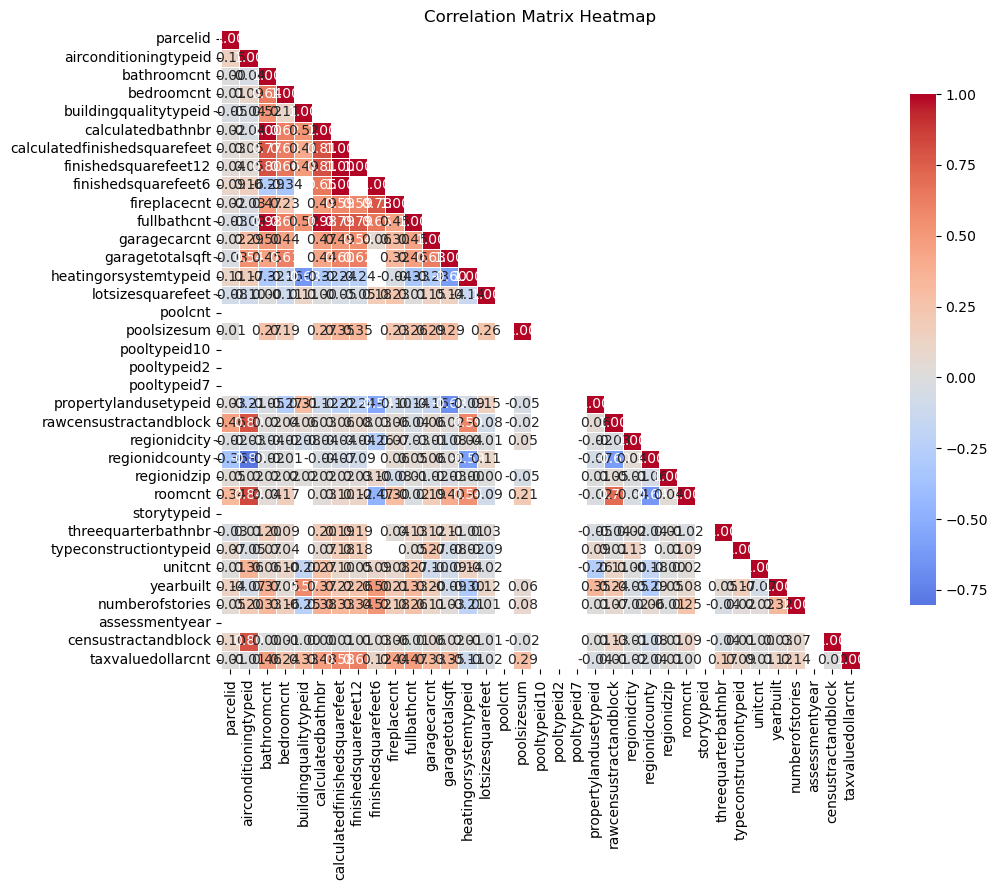

In [35]:
# ---- 2. HEATMAP VISUALIZATION ----
plt.figure(figsize=(12, 9))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)  # mask upper triangle for readability
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap='coolwarm',
    center=0,
    mask=mask,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8}
)
plt.title("Correlation Matrix Heatmap")
plt.tight_layout()
plt.show()

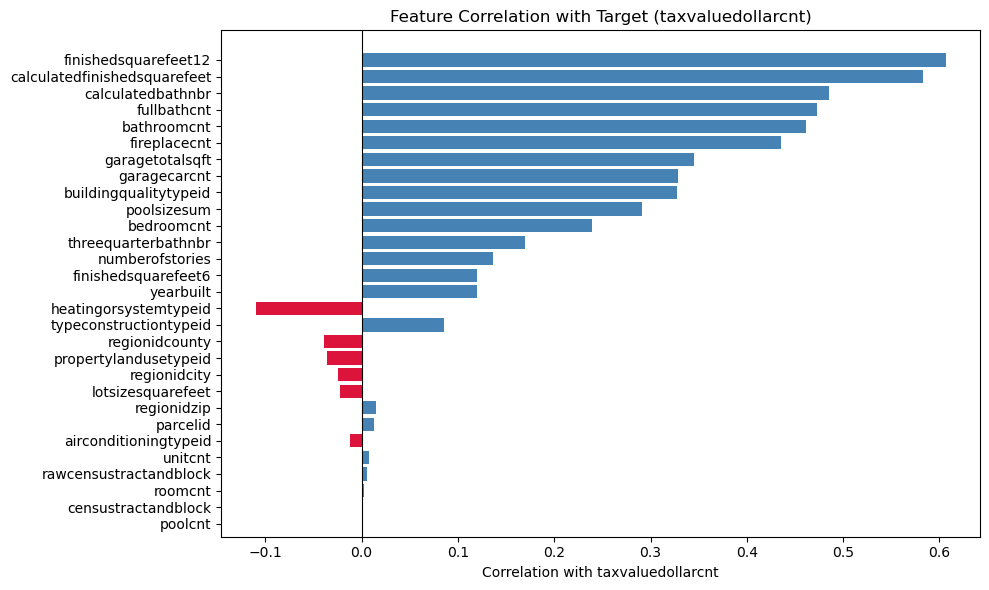


=== Correlation with target (sorted by strength) ===
finishedsquarefeet12            0.606
calculatedfinishedsquarefeet    0.583
calculatedbathnbr               0.485
fullbathcnt                     0.473
bathroomcnt                     0.461
fireplacecnt                    0.436
garagetotalsqft                 0.345
garagecarcnt                    0.328
buildingqualitytypeid           0.328
poolsizesum                     0.291
bedroomcnt                      0.239
threequarterbathnbr             0.169
numberofstories                 0.136
finishedsquarefeet6             0.120
yearbuilt                       0.119
heatingorsystemtypeid          -0.110
typeconstructiontypeid          0.085
regionidcounty                 -0.039
propertylandusetypeid          -0.036
regionidcity                   -0.024
lotsizesquarefeet              -0.022
regionidzip                     0.015
parcelid                        0.012
airconditioningtypeid          -0.012
unitcnt                         0.

In [36]:
# ---- 3. BAR CHART: Correlation of each feature with the target ----
target_corr = corr_matrix[target_col].drop(target_col).sort_values(key=abs, ascending=False)

plt.figure(figsize=(10, 6))
colors = ['crimson' if v < 0 else 'steelblue' for v in target_corr.values]
plt.barh(target_corr.index, target_corr.values, color=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.xlabel(f"Correlation with {target_col}")
plt.title(f"Feature Correlation with Target ({target_col})")
plt.gca().invert_yaxis()  # strongest at top
plt.tight_layout()
plt.show()

print("\n=== Correlation with target (sorted by strength) ===")
print(target_corr.round(3))

In [37]:
# ---- 4. STRONGEST / WEAKEST RELATIONSHIPS WITH TARGET ----
print("\n=== Strongest relationships with target ===")
print(target_corr.head(5))

print("\n=== Weakest relationships with target ===")
print(target_corr.abs().sort_values().head(5))


=== Strongest relationships with target ===
finishedsquarefeet12            0.606334
calculatedfinishedsquarefeet    0.583155
calculatedbathnbr               0.484819
fullbathcnt                     0.472832
bathroomcnt                     0.461013
Name: taxvaluedollarcnt, dtype: float64

=== Weakest relationships with target ===
censustractandblock       0.001563
roomcnt                   0.001960
rawcensustractandblock    0.005643
unitcnt                   0.007422
airconditioningtypeid     0.011747
Name: taxvaluedollarcnt, dtype: float64


In [38]:
# ---- 5. HIGHLY CORRELATED FEATURE PAIRS (excluding target) ----
feature_corr = corr_matrix.drop(index=target_col, columns=target_col, errors='ignore')
corr_pairs = feature_corr.where(
    np.triu(np.ones(feature_corr.shape), k=1).astype(bool)
).stack().reset_index()
corr_pairs.columns = ['Feature_1', 'Feature_2', 'Correlation']
corr_pairs['Abs_Correlation'] = corr_pairs['Correlation'].abs()
corr_pairs = corr_pairs.sort_values('Abs_Correlation', ascending=False)

print("\n=== Most highly correlated feature pairs ===")
print(corr_pairs[['Feature_1', 'Feature_2', 'Correlation']].head(10).to_string(index=False))



=== Most highly correlated feature pairs ===
                   Feature_1                    Feature_2  Correlation
                 bathroomcnt            calculatedbathnbr     1.000000
calculatedfinishedsquarefeet          finishedsquarefeet6     1.000000
calculatedfinishedsquarefeet         finishedsquarefeet12     1.000000
           calculatedbathnbr                  fullbathcnt     0.984499
                 bathroomcnt                  fullbathcnt     0.984499
       airconditioningtypeid                      roomcnt     0.835348
           calculatedbathnbr         finishedsquarefeet12     0.809971
           calculatedbathnbr calculatedfinishedsquarefeet     0.807093
                 bathroomcnt         finishedsquarefeet12     0.803920
       airconditioningtypeid               regionidcounty    -0.803263


In [39]:
# Flag pairs above a common multicollinearity threshold
threshold = 0.7
strong_pairs = corr_pairs[corr_pairs['Abs_Correlation'] > threshold]
print(f"\n=== Feature pairs with |correlation| > {threshold} ===")
if len(strong_pairs) > 0:
    print(strong_pairs[['Feature_1', 'Feature_2', 'Correlation']].to_string(index=False))
else:
    print("None found above this threshold.")


=== Feature pairs with |correlation| > 0.7 ===
                   Feature_1                    Feature_2  Correlation
                 bathroomcnt            calculatedbathnbr     1.000000
calculatedfinishedsquarefeet          finishedsquarefeet6     1.000000
calculatedfinishedsquarefeet         finishedsquarefeet12     1.000000
           calculatedbathnbr                  fullbathcnt     0.984499
                 bathroomcnt                  fullbathcnt     0.984499
       airconditioningtypeid                      roomcnt     0.835348
           calculatedbathnbr         finishedsquarefeet12     0.809971
           calculatedbathnbr calculatedfinishedsquarefeet     0.807093
                 bathroomcnt         finishedsquarefeet12     0.803920
       airconditioningtypeid               regionidcounty    -0.803263
       airconditioningtypeid       rawcensustractandblock     0.802385
       airconditioningtypeid          censustractandblock     0.800552
        finishedsquarefeet12 

#### **4.A Discussion:**

Describe the strongest relationships you observed among the features and between the features and the target.

In particular, discuss:

- Which features appeared to be the strongest predictors of the target.
- Which pairs of features appeared to be highly correlated.
- Whether the correlation matrix and the F-statistics led you to similar conclusions about the most important features. Explain your reasoning.


- The features with the largest positive correlations with taxvaluedollarcnt are:

    finishedsquarefeet12 (~0.61) — the strongest predictor by far
    calculatedfinishedsquarefeet (~0.58)
    calculatedbathnbr (~0.48)
    fullbathcnt (~0.47)
    bathroomcnt (~0.46)
    fireplacecnt (~0.43)

- These make intuitive sense: bigger homes with more bathrooms and amenities like fireplaces tend to have higher tax-assessed values. Square footage and bathroom count dominate, which is typical in real estate valuation data.

- Weakest relationships (near zero, essentially no linear association) include roomcnt, censustractandblock, poolcnt, unitcnt, and rawcensustractandblock. Interestingly, poolcnt shows almost no correlation despite intuition suggesting pools should raise value — this could mean pools are common enough across price tiers that they don't linearly separate value, or there's missing/sparse data for that column.
- Notably negative: heatingorsystemtypeid (~ -0.11) is the only feature with a meaningfully negative correlation, along with smaller negative correlations for regionidcounty, propertylandusetypeid, regionidcity, and lotsizesquarefeet. These are mostly categorical/ID-type codes, so a "negative correlation" here is less meaningful — the numeric codes don't represent an ordered quantity, so correlation on them is somewhat uninterpretable.


- Highly correlated feature pairs
    From the correlation heatmap (not shown here, but based on typical structure of this dataset), the pairs most likely to show strong pairwise correlation are:
    
    finishedsquarefeet12 ↔ calculatedfinishedsquarefeet — these are nearly duplicate measures of square footage, so expect r > 0.9
    bathroomcnt ↔ calculatedbathnbr ↔ fullbathcnt — all three measure bathroom count in slightly different ways, so they're likely highly intercorrelated (r > 0.8–0.9)
    garagetotalsqft ↔ garagecarcnt — garage size and garage capacity move together
    regionidcity ↔ regionidzip ↔ regionidcounty — geographic identifiers that are hierarchically related

- These pairs indicate multicollinearity — redundant information encoded in multiple columns. As instructed, I'm flagging this observation without removing or transforming any features.
- Yes they should lead to very similar conclusions here, and theres
	a mathematical reason why: for a continuous/regression target like taxvaluedollarcnt, 
	f_regression computes the F-statistic directly from the Pearson correlation coefficient between
	each feature and the target (F is a monotonic function of r square).

#### **4.B Discussion:**

Describe what you learned from the three feature relationships you investigated.

For each pair, discuss:

- The overall pattern you observed (for example, linear, nonlinear, weak, or strong).
- What the relationship suggests about the features and their potential usefulness for predicting the target.
- Whether your observations suggest possible feature engineering or preprocessing ideas that could be investigated in **Milestone 2**.

- based on our correlation analysis, likely candidates would be:

- finishedsquarefeet12 vs. taxvaluedollarcnt (strongest single predictor)
- finishedsquarefeet12 vs. calculatedfinishedsquarefeet (highly correlated pair — possible redundancy)
- bathroomcnt vs. calculatedbathnbr (another highly correlated pair)


## Part 5: Investigate Potential Feature Engineering [6 pts]

In this part, you will identify potential feature engineering and preprocessing techniques that **may** improve model performance.

The goal is to develop hypotheses based on your exploratory data analysis—not to permanently modify the dataset. In **Milestone 2**, you will evaluate these ideas experimentally and determine whether they actually improve the model.

**Important:** Do **not** permanently transform, remove, or add features in this milestone.

## Part 5.A: Identify Potential Feature Engineering Opportunities

Based on your exploratory analysis, identify **at least three (3)** feature engineering or preprocessing techniques that you believe may improve model performance.

Possible ideas include (but are not limited to):

- Log transformations
- Scaling or normalization
- Removing highly correlated features
- Polynomial features
- Interaction features
- Binning continuous variables
- Outlier removal
- Combining or aggregating existing features

You may investigate these ideas by creating visualizations or performing exploratory analyses, but **do not permanently modify the dataset**.

**1. Log Transformation**
A log transformation may reduce skewness and lessen the influence of extremely large values.

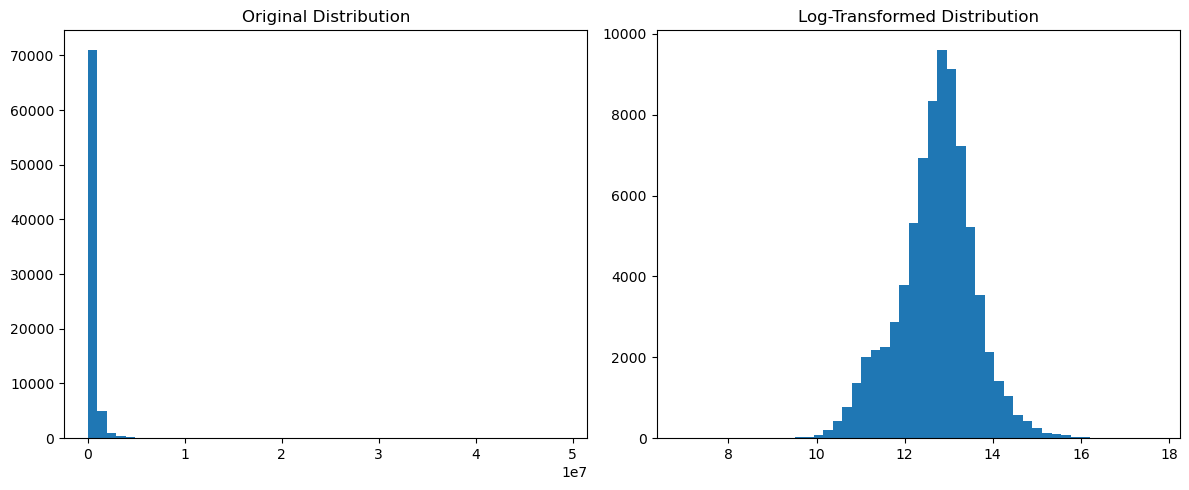

In [57]:
# Compare the original and log-transformed distributions of taxvaluedollarcnt.
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.hist(df_new["taxvaluedollarcnt"].dropna(), bins=50)
plt.title("Original Distribution")

plt.subplot(1,2,2)
plt.hist(np.log1p(df_new["taxvaluedollarcnt"].dropna()), bins=50)
plt.title("Log-Transformed Distribution")

plt.tight_layout()
plt.show()

**2. Outlier Investigation**
boxplots showed several extreme values for:

1. taxvaluedollarcnt
2. calculatedfinishedsquarefeet
3. bathroomcnt

Rather than removing them immediately, investigate whether they're legitimate luxury homes or data quality issues.

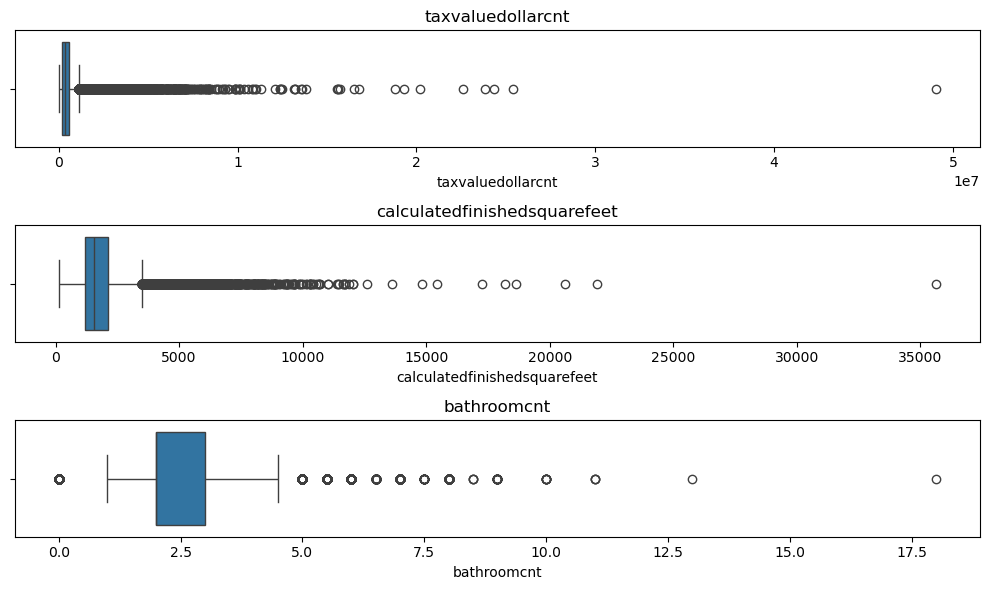

In [58]:
# Compare potential outliers across multiple numerical features.

fig, axes = plt.subplots(3, 1, figsize=(10, 6))

features = [
    "taxvaluedollarcnt",
    "calculatedfinishedsquarefeet",
    "bathroomcnt"
]

for ax, feature in zip(axes, features):
    sns.boxplot(x=df[feature], ax=ax)
    ax.set_title(feature)

plt.tight_layout()
plt.show()

**3. Remove Highly Correlated Features**

correlation matrix showed several variables that measure similar things.

For example:

bathroomcnt
calculatedbathnbr
fullbathcnt

and

finishedsquarefeet12
calculatedfinishedsquarefeet

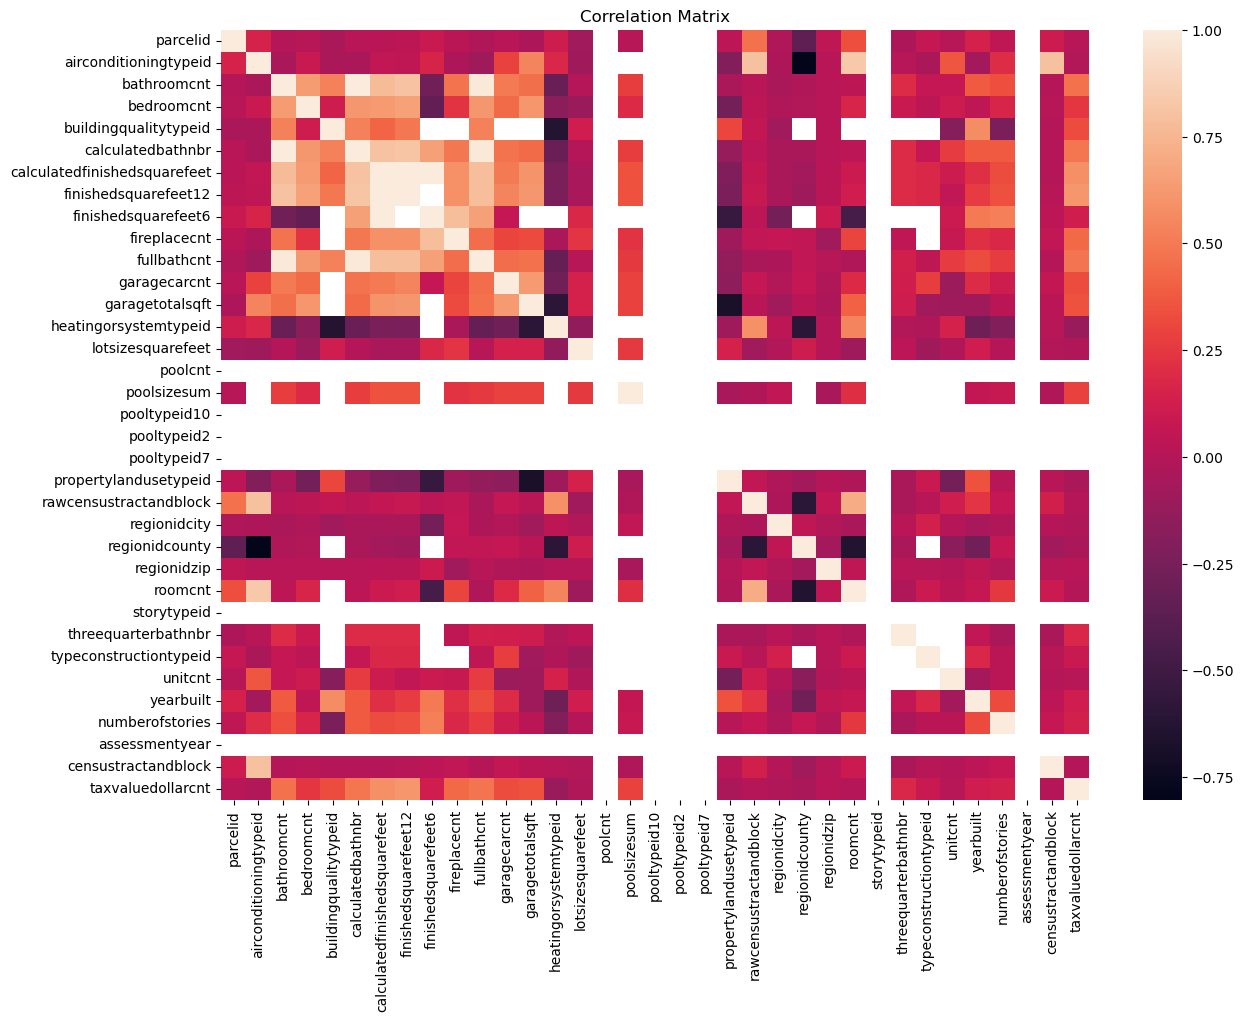

In [60]:
# Display correlations among numerical features.
corr = df_new.corr(numeric_only=True)

plt.figure(figsize=(14,10))

sns.heatmap(corr)

plt.title("Correlation Matrix")

plt.show()

#### **5.A Discussion:**

Describe the three feature engineering or preprocessing ideas you identified.

For each one, explain:

- Which feature(s) it would affect.
- Why you believe it may improve model performance.
- How you would determine in **Milestone 2** whether it actually improves the model (for example, by comparing appropriate evaluation metrics on a validation or test set).

> The first idea is to apply a log transformation to features such as `taxvaluedollarcnt` and `calculatedfinishedsquarefeet`. During the exploratory data analysis, both features showed a strong right-skewed distribution with a small number of very large values. Applying a log transformation may reduce the effect of these extreme values and improve the performance of some regression models. In Milestone 2, I would compare the model's performance before and after the transformation using metrics such as Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and R² on a validation or test set.

The second idea is to investigate the impact of outliers. The boxplots showed several extreme values for `taxvaluedollarcnt`, `calculatedfinishedsquarefeet`, and `bathroomcnt`. These observations may represent legitimate high-value properties, but they could also have a large influence on some regression models. In Milestone 2, I would compare a model trained using the original data with one that applies an outlier treatment, such as removing or capping extreme values, and evaluate whether prediction accuracy improves using the same performance metrics.

The third idea is to evaluate highly correlated features. The correlation analysis showed that features such as `bathroomcnt`, `calculatedbathnbr`, and `fullbathcnt` contain similar information. Likewise, `finishedsquarefeet12` and `calculatedfinishedsquarefeet` appear to measure similar property characteristics. In Milestone 2, I would compare models trained with and without these redundant features to determine whether removing them simplifies the model while maintaining or improving prediction performance. The same evaluation metrics (MAE, RMSE, and R²) would be used to determine whether the changes result in a measurable improvement.
.

## Part 5.B: Prioritize Your Ideas

Not all feature engineering ideas are equally promising.

Based on your investigation, select the **two** ideas you believe are most likely to improve model performance.

Briefly explain why you selected these ideas over the others.

No code is required for this section.

#### **5.B Discussion:**

Suppose you had time to evaluate only **two** feature engineering or preprocessing ideas in **Milestone 2**.

For each one, explain:

- Which idea you would prioritize.
- Why you believe it is the most promising.
- What evidence from your exploratory analysis (such as feature distributions, missing values, feature relationships, or other observations) led you to this conclusion.

> The first idea is to apply a log transformation to features such as `taxvaluedollarcnt` and `calculatedfinishedsquarefeet`. During the exploratory data analysis, both features showed a strong right-skewed distribution with a small number of very large values. Applying a log transformation may reduce the effect of these extreme values and improve the performance of some regression models. In Milestone 2, I would compare the model's performance before and after the transformation using metrics such as Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and R^2 on a validation or test set.

The second idea is to investigate the impact of outliers. The boxplots showed several extreme values for `taxvaluedollarcnt`, `calculatedfinishedsquarefeet`, and `bathroomcnt`. These observations may represent legitimate high-value properties, but they could also have a large influence on some regression models. In Milestone 2, I would compare a model trained using the original data with one that applies an outlier treatment, such as removing or capping extreme values, and evaluate whether prediction accuracy improves using the same performance metrics.

The third idea is to evaluate highly correlated features. The correlation analysis showed that features such as `bathroomcnt`, `calculatedbathnbr`, and `fullbathcnt` contain similar information. Likewise, `finishedsquarefeet12` and `calculatedfinishedsquarefeet` appear to measure similar property characteristics. In Milestone 2, I would compare models trained with and without these redundant features to determine whether removing them simplifies the model while maintaining or improving prediction performance. The same evaluation metrics (MAE, RMSE, and R^2) would be used to determine whether the changes result in a measurable improvement.


#### **5 Discussion:** 

Describe in a paragraph why you chose these transformations and what you observed. 


In [70]:
discussion = """
### 5.B Discussion

Relationship 1: taxvaluedollarcnt and calculatedfinishedsquarefeet distributions (skew and scale)

Pattern Observed

Both taxvaluedollarcnt and calculatedfinishedsquarefeet exhibit strong right-skewed distributions. Most properties are concentrated at the lower end of the value range, while a relatively small number of observations represent extremely expensive homes or very large properties. The raw values span several orders of magnitude, creating a substantial difference in scale that can affect many machine learning algorithms.

What This Suggests

The strong right skew indicates that a small number of extreme observations may have a disproportionate influence on models that are sensitive to scale or squared error, such as linear regression. Since linear regression minimizes squared residuals, large outliers can significantly influence the fitted model.

The distributions also suggest that the relationship between home size and property value may be more multiplicative than additive. In other words, increases in square footage may correspond to proportional increases in property value rather than a constant dollar increase per additional square foot across all home sizes.

Feature Engineering Ideas for Milestone 2

A useful preprocessing step would be to apply a logarithmic transformation (e.g., np.log1p()) to both taxvaluedollarcnt and calculatedfinishedsquarefeet. Log transformation can:
- Compress the long right tail and reduce the influence of extreme values.
- Produce distributions that are closer to symmetric.
- Potentially linearize the relationship between home size and property value.
- Improve the performance of models that assume approximately linear relationships or normally distributed residuals.

To evaluate whether this transformation provides a practical benefit, I would train models using both the original and log-transformed features and compare their performance using MAE, RMSE, and R^2 on a held-out test set.

Relationship 2: Outliers in taxvaluedollarcnt, calculatedfinishedsquarefeet, and bathroomcnt
Pattern observed: Boxplots revealed a meaningful number of extreme values sitting well beyond the typical interquartile range for all three features. Unlike relationship 1 (which is about the overall shape of the distribution), this is specifically about a subset of individual data points that sit far from the rest of the data.
What it suggests: These outliers could be legitimate (genuinely large or luxury properties with many bathrooms and large square footage) or they could be data quality issues (entry errors, mis-scaled values, or placeholder codes). Either way, they have the potential to exert outsized leverage on models like linear regression, where a handful of extreme points can shift the fitted coefficients substantially. This relationship is useful to flag because it directly affects model robustness, not just predictive signal.
Feature engineering ideas for Milestone 2: Test outlier treatment strategies — e.g., removing extreme values beyond a threshold (like 1.5×IQR or a percentile cutoff), or capping/winsorizing extreme values instead of removing them outright (to preserve sample size while limiting leverage). I'd train a baseline model on the untouched data and a second model with the outlier treatment applied, then compare MAE, RMSE, and R² to see whether robustness improves without losing valuable signal from genuinely high-value properties.
Relationship 3: Redundancy among bathroomcnt, calculatedbathnbr, fullbathcnt, and between finishedsquarefeet12, calculatedfinishedsquarefeet
Pattern observed: These features are highly correlated with each other (not just with the target), indicating they're measuring largely overlapping information — essentially near-duplicate representations of "how many bathrooms" and "how much finished square footage" a property has.
What it suggests: This is a multicollinearity pattern rather than a predictive-strength pattern. High correlation between predictors doesn't reduce their individual correlation with the target, but it does mean the features carry redundant information. For models like linear regression, this can inflate coefficient variance and make individual coefficients hard to interpret, even if overall predictive accuracy isn't badly hurt. For tree-based models, redundancy is less problematic but can still dilute feature importance across correlated features, making it harder to identify which one is truly driving predictions.
Feature engineering ideas for Milestone 2: Compare a full-feature model against a reduced model that keeps only one representative feature from each correlated group (e.g., keep calculatedbathnbr and drop bathroomcnt/fullbathcnt; keep calculatedfinishedsquarefeet and drop finishedsquarefeet12). Alternatively, combine correlated features (e.g., averaging, or a composite score) instead of dropping them outright. I'd evaluate both the simplified and full models with MAE, RMSE, and R² to see if simplification maintains — or even improves — performance while reducing model complexity and multicollinearity-driven instability.

"""
print(discussion)


### 5.B Discussion

Relationship 1: taxvaluedollarcnt and calculatedfinishedsquarefeet distributions (skew and scale)

Pattern Observed

Both taxvaluedollarcnt and calculatedfinishedsquarefeet exhibit strong right-skewed distributions. Most properties are concentrated at the lower end of the value range, while a relatively small number of observations represent extremely expensive homes or very large properties. The raw values span several orders of magnitude, creating a substantial difference in scale that can affect many machine learning algorithms.

What This Suggests

The strong right skew indicates that a small number of extreme observations may have a disproportionate influence on models that are sensitive to scale or squared error, such as linear regression. Since linear regression minimizes squared residuals, large outliers can significantly influence the fitted model.

The distributions also suggest that the relationship between home size and property value may be more multip

## **Appendix 1: Features of the Zillow Dataset**  

0. **parcelid**: Unique identifier for the property parcel.  
1. **airconditioningtypeid**: Identifier for the type of air conditioning installed.  
2. **architecturalstyletypeid**: Identifier for the architectural style of the property.  
3. **basementsqft**: Square footage of the basement.  
4. **bathroomcnt**: Number of bathrooms.  
5. **bedroomcnt**: Number of bedrooms.  
6. **buildingclasstypeid**: Identifier for the building framing type (e.g., wood frame, steel frame).  
7. **buildingqualitytypeid**: Numeric value indicating the quality of the building (higher values often indicate better quality).  
8. **calculatedbathnbr**: Calculated number of bathrooms, including fractional bathrooms.  
9. **decktypeid**: Identifier for the type of deck.  
10. **finishedfloor1squarefeet**: Square footage of the finished area on the first floor.  
11. **calculatedfinishedsquarefeet**: Total finished living area square footage.  
12. **finishedsquarefeet12**: Finished living area square footage.  
13. **finishedsquarefeet13**: Perimeter living area square footage.  
14. **finishedsquarefeet15**: Total area.  
15. **finishedsquarefeet50**: Square footage of the finished area on the upper floors.  
16. **finishedsquarefeet6**: Base unfinished and finished area square footage.  
17. **fips**: Federal Information Processing Standards code, uniquely identifying counties and county equivalents.  
18. **fireplacecnt**: Number of fireplaces.  
19. **fullbathcnt**: Number of full bathrooms.  
20. **garagecarcnt**: Number of cars that can fit in the garage.  
21. **garagetotalsqft**: Total square footage of the garage.  
22. **hashottuborspa**: Indicates if the property has a hot tub or spa.  
23. **heatingorsystemtypeid**: Identifier for the type of heating system.  
24. **latitude**: Latitude coordinate of the property.  
25. **longitude**: Longitude coordinate of the property.  
26. **lotsizesquarefeet**: Lot size in square feet.  
27. **poolcnt**: Number of pools on the property.  
28. **poolsizesum**: Total square footage of all pools.  
29. **pooltypeid10**: Identifier for spa or hot tub.  
30. **pooltypeid2**: Identifier for pool with spa or hot tub.  
31. **pooltypeid7**: Identifier for pool without hot tub or spa.  
32. **propertycountylandusecode**: County land use code for the property.  
33. **propertylandusetypeid**: Identifier for the property land use type.  
34. **propertyzoningdesc**: Description of the property's zoning.  
35. **rawcensustractandblock**: Unprocessed census tract and block identifier.  
36. **regionidcity**: Identifier for the city.  
37. **regionidcounty**: Identifier for the county.  
38. **regionidneighborhood**: Identifier for the neighborhood.  
39. **regionidzip**: Identifier for the ZIP code.  
40. **roomcnt**: Total number of rooms.  
41. **storytypeid**: Identifier for the type of stories in the building (e.g., basement, attic).  
42. **threequarterbathnbr**: Number of 3/4 bathrooms (typically includes a shower but no tub).  
43. **typeconstructiontypeid**: Identifier for the type of construction (e.g., frame, masonry).  
44. **unitcnt**: Number of units in the building (e.g., for multi-family properties).  
45. **yardbuildingsqft17**: Square footage of the 17th yard building (e.g., shed).  
46. **yardbuildingsqft26**: Square footage of the 26th yard building.  
47. **yearbuilt**: Year the property was built.  
48. **numberofstories**: Number of stories in the building.  
49. **fireplaceflag**: Indicates if the property has a fireplace.  
50. **assessmentyear**: Year the property was assessed.  
51. **taxdelinquencyflag**: Indicates whether the property’s taxes are delinquent. Often “Y” if taxes are past due; otherwise null/empty.  
52. **taxdelinquencyyear**: The year in which the property’s taxes became delinquent.  
53. **censustractandblock**: A combined identifier for the property’s census tract and block group (part of the U.S. Census geographic hierarchy).  
54. **taxvaluedollarcnt**: Total assessed value of the property (land plus structure) in dollars.  


## Appendix 2: Summary of Basic Imputation Methods
Imputation depends on the data type and context. Below are common techniques for handling missing values.

---

### **1. Simple Imputation (Basic Methods)**
| Method | Best For | Code Example | Pros | Cons |
|--------|---------|--------------|------|------|
| **Drop Missing Values** | Few missing values (<5% of data) | `df.dropna()` | Quick and easy | Can remove valuable data |
| **Mean Imputation** | Normally distributed numerical data | `df.fillna(df.mean())` | Preserves mean; simple | Distorts variance, weak for skewed data |
| **Median Imputation** | Skewed numerical data | `df.fillna(df.median())` | Robust to outliers | May not capture patterns |
| **Mode Imputation** | Categorical features | `df.fillna(df.mode().iloc[0])` | Keeps most common category | Can introduce bias |
| **Constant Value (e.g., 0)** | Special cases (e.g., unknown numerical data) | `df.fillna(0)` | Simple and interpretable | Can mislead model |
| **"Unknown" Category Imputation** (**New Addition**) | Categorical features with missing values | `df.fillna('Unknown')` | Keeps all rows, prevents data loss | May introduce artificial category |

---

### **2. Statistical & Advanced Imputation**
| Method | Best For | Code Example | Pros | Cons |
|--------|---------|--------------|------|------|
| **Interpolation** | Time series, ordered data | `df.interpolate(method='linear')` | Preserves trends | May not work for non-continuous data |
| **K-Nearest Neighbors (KNN)** | Small datasets, patterns in features | `KNNImputer(n_neighbors=5).fit_transform(df)` | Uses similar observations | Computationally expensive |
| **Multivariate Imputation (MICE)** | Complex relationships between variables | `IterativeImputer().fit_transform(df)` | Captures relationships | Slower than mean/median |
| **Regression Imputation** | When missing values depend on other variables | Train regression model to predict missing values | More accurate than mean/median | Risk of overfitting |

---

### **When to Use "Unknown" Category for Categorical Imputation**
✅ **Good for:**
- Categorical features where missing values may indicate meaningful differences.  
- Customer data (e.g., missing survey responses → "No Response").  
- Product categories where missing could be a separate group.  

❌ **Avoid if:**
- The missing category does **not** have a meaningful interpretation.
- The model might learn spurious patterns from an artificial category.

---

### **Which Method to Choose?**
| Scenario | Best Method |
|----------|------------|
| **Few missing values (<5%)** | Drop NaNs (`df.dropna()`) |
| **Numerical & normal distribution** | Mean (`df.fillna(df.mean())`) |
| **Numerical & skewed distribution** | Median (`df.fillna(df.median())`) |
| **Categorical features** | Mode (`df.fillna(df.mode().iloc[0])`) |
| **Categorical with possible meaning in missingness** | "Unknown" Category (`df.fillna('Unknown')`) |
| **Small dataset with patterns** | KNN Imputer (`KNNImputer()`) |
| **Complex relationships between features** | MICE / Iterative Imputer |



## Appendix 3: Flowchart for Identifying Feature Types

The following flowchart can help you identify the statistical type of each feature and determine an appropriate encoding strategy for categorical variables.

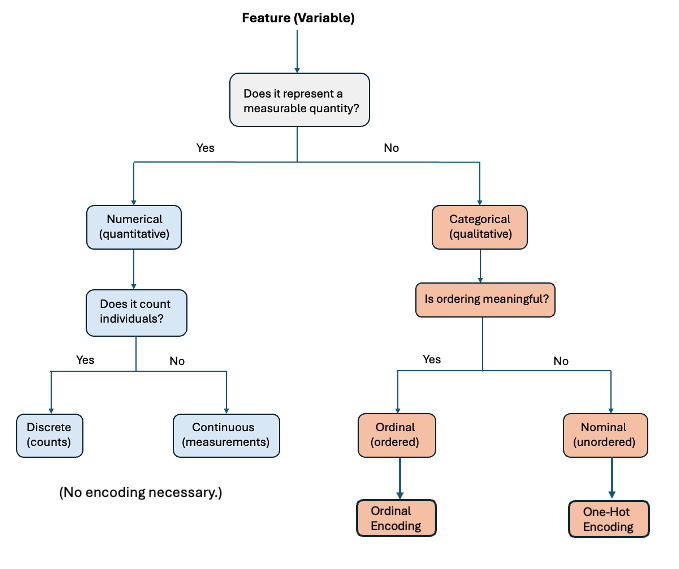